# N-Grams

**Student Name:** Danyal Salman Alhashem  
**Student ID:** 2240002713

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

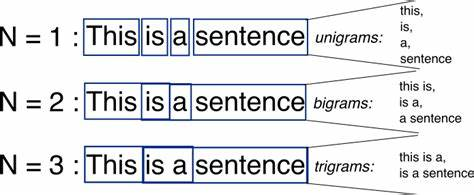

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** an n-gram consisting of a single item from a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$ count of (A) \div corpus length $

In [1]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [2]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('toeses', 1),
 ('his', 1),
 ('moses', 2),
 ('but', 1),
 ('are', 1),
 ('erroneously', 1),
 ('supposes', 2),
 ('roses', 1)]

In [3]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(string)
    probab.append(pro)

print('the probabilities are: ',probab)

the probabilities are:  [0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.015151515151515152]


In [4]:
probabilities = []
for i,j in zip(unique_string, probab):
    probabilities.append((i,j))
probabilities

[('toeses', 0.015151515151515152),
 ('his', 0.015151515151515152),
 ('moses', 0.030303030303030304),
 ('but', 0.015151515151515152),
 ('are', 0.015151515151515152),
 ('erroneously', 0.015151515151515152),
 ('supposes', 0.030303030303030304),
 ('roses', 0.015151515151515152)]

## Bigram

**Bigram** an n-gram consisting of two items from a sequence
- Two words that are used together to mean something specific

$ countof(A \ then \ B) \div countof(A) $

### Method 1

In [5]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nl.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [6]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [7]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nl.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [8]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in 1.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

n-1 padding is added.



In [9]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [10]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.

- Build the vocabulary: to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create and Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.


**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [11]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [12]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model
print(lm.vocab)
print(len(lm.vocab))

<Vocabulary with cutoff=1 unk_label='<UNK>' and 11 items>
11


In [13]:
lm.vocab.lookup(['moses','supposes'])

('moses', 'supposes')

In [14]:
lm.vocab.lookup(['moses'])

('moses',)

### counts for unigrams and bigrams

In [15]:
print(lm.counts['moses'])
# a then b
print(lm.counts[['moses']]['supposes'])

2
2


In [16]:
print(lm.score('moses')) #Calculate Bigram Probabilities

0.16666666666666666


Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [17]:
# b then a
lm.score("supposes", ["moses"])

1.0

### Evaluating n_grams models using preplexity

**Preplexity** is the probability of the test set normalized by the number of words

In [18]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test))

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions




3. build MLE model with n-gram
4. evaluate the model

before we start we need to install library to handle the emojis in tweets
> pip install emoji

# 📘 LAB 3 — Solutions

This notebook completes the three required tasks on the **real Kaggle datasets**:

| # | Task | Kaggle file |
|---|------|-------------------------------------------|
| Part 1 – Task 1 | Generate tweets with an MLE N‑gram model + required counts / probabilities / perplexity | `Random Tweets from Pakistan- Cleaned- Anonymous.csv` |
| Part 2 – Task 1 | Text analysis of movie reviews (stats + word‑frequency histogram) | `IMDB Dataset.csv` |
| Part 2 – Task 2 | Generate bi‑grams and list the top‑10 | `Poem_classification - train_data.csv` |

Each loader reads its **real Kaggle CSV**. If a file is missing, the cell raises a clear
`FileNotFoundError` instead of producing any placeholder result.

### Dataset paths

The following paths point to the real Kaggle CSV files in the Downloads folder.


In [19]:
# Local paths to the required datasets
TWEETS_CSV = r'C:\Users\danya\Downloads\Random Tweets from Pakistan- Cleaned- Anonymous.csv'
IMDB_CSV = r'C:\Users\danya\Downloads\IMDB Dataset.csv'
POEM_TEST_CSV = r'C:\Users\danya\Downloads\Poem_classification - test_data.csv'
POEM_CSV = r'C:\Users\danya\Downloads\Poem_classification - train_data.csv'

print('Dataset paths configured.')


Dataset paths configured.


---
## Part 1 – Task 1: Generating tweets using N‑grams

**Dataset:** [Random Tweets from Pakistan | Kaggle](https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan)

**Steps:** load → pre‑process (remove mentions, hashtags, RT, URLs, extra symbols/spaces, emojis; lower‑case) → build the **Bigram** MLE model → evaluate, then compute the required counts, probabilities and perplexity.

> As required by the instructions, the main model is a **Bigram** `MLE(2)` (used for tweet
> generation, the bigram probabilities and the perplexity). Because the task **also** asks
> for a *trigram* count and `P('a' | 'pakistan is')`, a separate **Trigram** `MLE(3)` is
> built just for those two trigram‑level results.

In [20]:
# If needed (run once, keep the ! for Jupyter):  !pip install nltk emoji
import os, re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.lm import MLE
import emoji

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

### Step 1 — Load the data (real Kaggle file)

In [21]:
# Load the real Kaggle file using the configured Downloads path.
tweets = pd.read_csv(TWEETS_CSV, encoding='latin1', low_memory=False)
tweets = tweets.dropna(subset=['full_text'])          # remove missing tweets
tweets_raw = tweets['full_text'].astype(str).tolist()

print("Number of tweets loaded:", len(tweets_raw))
tweets[['full_text']].head()

Number of tweets loaded: 202151


,full_text
0,ØªÛØ±Ø§ ÙÛÚØ± Ù ÛØ±Ø§ ÙÛÚØ± ÙÙØ§Ø² Ø...
1,"Happy birthday to my brother n boss , May you ..."
2,â¤ï¸â¤ï¸
3,`suspicious Â°jikook au jimin'in yaÅadÄ±ÄÄ± ...
4,Speaking of @SpiderMan... ð https://t.co/...


### Step 2 — Pre‑process the tweets

Cleaning removes **mentions**, **hashtags**, **RT**, **URLs**, **extra symbols**,
**extra spaces** and **emojis**, then lower‑cases the text.

In [22]:
def clean_tweet(t):
    t = str(t)
    t = emoji.replace_emoji(t, replace='')          # remove emojis
    t = re.sub(r'@\w+', ' ', t)                     # remove mentions
    t = re.sub(r'#\w+', ' ', t)                     # remove hashtags
    t = re.sub(r'\bRT\b', ' ', t)                   # remove RT
    t = re.sub(r'http\S+|www\.\S+', ' ', t)         # remove URLs / websites
    t = re.sub(r'[^a-zA-Z\s]', ' ', t)              # remove extra symbols
    t = re.sub(r'\s+', ' ', t).strip().lower()      # remove extra spaces + lowercase
    return t

cleaned = [clean_tweet(t) for t in tweets_raw]
tokenized_tweets = [word_tokenize(s) for s in cleaned if s.strip()]

print("Usable tweets after cleaning:", len(tokenized_tweets))
print("Example cleaned tweet:", cleaned[0])
print("Example tokenized     :", tokenized_tweets[0])

Usable tweets after cleaning: 143247
Example cleaned tweet: 
Example tokenized     : ['happy', 'birthday', 'to', 'my', 'brother', 'n', 'boss', 'may', 'you', 'have', 'many', 'many', 'more', 'you', 'are', 'gem']


### Step 3 — Build the Bigram MLE model (`MLE(2)`)

In [23]:
# Bigram model (n = 2) — the model required by the instructions
train_bi, vocab_bi = padded_everygram_pipeline(2, tokenized_tweets)
bigram_model = MLE(2)
bigram_model.fit(train_bi, vocab_bi)

print("Bigram model vocabulary size:", len(bigram_model.vocab))

Bigram model vocabulary size: 76221


### Step 4 — Build a separate Trigram model (`MLE(3)`)

Only used for the **trigram count** and `P('a' | 'pakistan is')`.

In [24]:
train_tri, vocab_tri = padded_everygram_pipeline(3, tokenized_tweets)
trigram_model = MLE(3)
trigram_model.fit(train_tri, vocab_tri)

print("Trigram model vocabulary size:", len(trigram_model.vocab))

Trigram model vocabulary size: 76221


### Step 5 — Required counts

In [25]:
count_unigram = bigram_model.counts['pakistan']                 # 'pakistan'
count_bigram  = bigram_model.counts[['is']]['pakistan']         # 'is pakistan'
count_trigram = trigram_model.counts[['a', 'pakistan']]['is']   # 'a pakistan is'

print("Count of unigram 'pakistan'      :", count_unigram)
print("Count of bigram  'is pakistan'   :", count_bigram)
print("Count of trigram 'a pakistan is' :", count_trigram)

Count of unigram 'pakistan'      : 14010
Count of bigram  'is pakistan'   : 130
Count of trigram 'a pakistan is' : 0


### Step 6 — Required probabilities

In [26]:
p_pak_given_s   = bigram_model.score('pakistan', ['<s>'])       # P('pakistan' | <s>)
p_is_given_pak  = bigram_model.score('is', ['pakistan'])        # P('is' | 'pakistan')
p_a_given_pakis = trigram_model.score('a', ['pakistan', 'is'])  # P('a' | 'pakistan is')

print("P('pakistan' | <s>)    :", p_pak_given_s)
print("P('is' | 'pakistan')   :", p_is_given_pak)
print("P('a' | 'pakistan is') :", p_a_given_pakis)

P('pakistan' | <s>)    : 0.009717480994366375
P('is' | 'pakistan')   : 0.049892933618843685
P('a' | 'pakistan is') : 0.10014306151645208


### Step 7 — Perplexity of the Bigram model

MLE has no smoothing, so an n‑gram never seen in training gets probability 0. We
therefore evaluate perplexity on bigrams taken from the corpus itself.

In [27]:
test_bigrams = []
for toks in tokenized_tweets[:200]:                 # a sample of the corpus
    test_bigrams += list(ngrams(pad_both_ends(toks, n=2), n=2))

print("Perplexity of the Bigram model:", bigram_model.perplexity(test_bigrams))

Perplexity of the Bigram model: 94.12695522495576


### Step 8 — Generate a tweet with the Bigram model

In [28]:
def generate_tweet(model, num_words=20, seed=7):
    words = []
    for w in model.generate(num_words, random_seed=seed):
        if w == '</s>':
            break
        if w != '<s>':
            words.append(w)
    return ' '.join(words)

print("Generated tweet:", generate_tweet(bigram_model))

Generated tweet: embassy hostage rescue again in karachi


---
## Part 2 – Task 1: Text Analysis and NLP (IMDB reviews)

**Dataset:** [IMDB Dataset of 50K Movie Reviews | Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Steps:** load → pre‑process (tokenize, remove punctuation, lower‑case, remove stop
words) → statistics → word‑frequency histogram → print results.

In [29]:
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

imdb = pd.read_csv(IMDB_CSV)
print("Shape:", imdb.shape)
imdb.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Step 1 — Pre‑process the reviews

Each review is lower‑cased, tokenized into words while dropping punctuation
(regex `[a-z]+`), and stripped of English stop words. HTML tags such as `<br />`
are removed first. The result is stored in a **`tokens`** column.

In [30]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)                     # remove HTML tags like <br />
    tokens = re.findall(r'[a-z]+', text)                   # tokenize + remove punctuation
    tokens = [w for w in tokens if w not in stop_words]    # remove English stop words
    return tokens

imdb['tokens'] = imdb['review'].apply(preprocess)
imdb[['review', 'tokens']].head(3)

,review,tokens
0,One of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."


### Step 2 — Statistics

In [31]:
# Total number of reviews
total_reviews = len(imdb)

# Average (processed) word count per review — using the cleaned 'tokens'
avg_word_count = imdb['tokens'].apply(len).mean()

# Reviews containing the complete word 'good' / 'bad'
good_re = re.compile(r'\bgood\b', re.I)
bad_re  = re.compile(r'\bbad\b',  re.I)
num_good = imdb['review'].apply(lambda r: bool(good_re.search(str(r)))).sum()
num_bad  = imdb['review'].apply(lambda r: bool(bad_re.search(str(r)))).sum()

print("Total number of reviews              :", total_reviews)
print(f"Average processed word count / review: {avg_word_count:.2f}")
print("Reviews containing the word 'good'   :", num_good)
print("Reviews containing the word 'bad'    :", num_bad)

Total number of reviews              : 50000
Average processed word count / review: 118.15
Reviews containing the word 'good'   : 19004
Reviews containing the word 'bad'    : 11788


### Step 3 — Word‑frequency histogram (most common words)

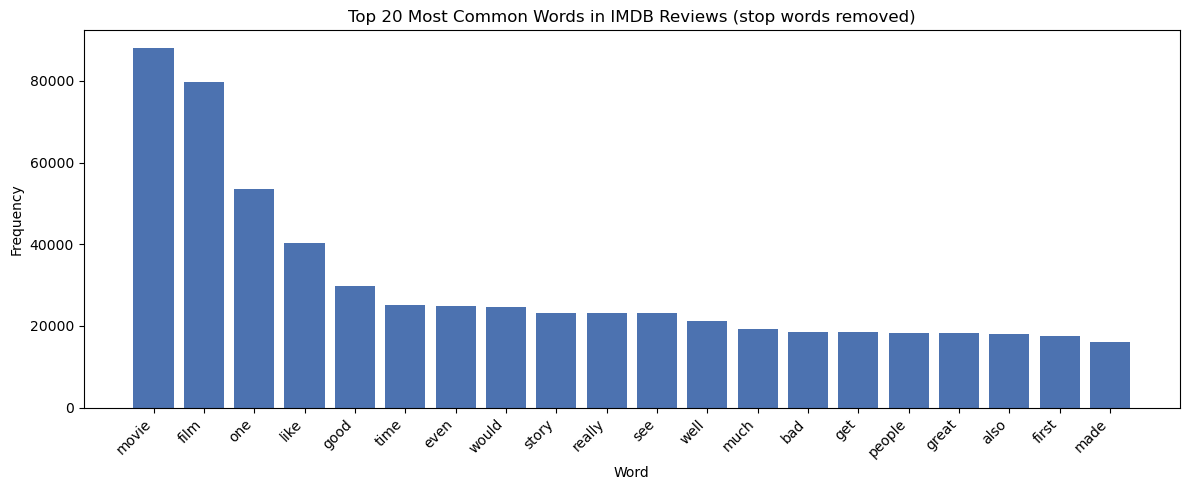

In [32]:
all_words = Counter()
for toks in imdb['tokens']:
    all_words.update(toks)

top_n = 20
common = all_words.most_common(top_n)
words  = [w for w, c in common]
counts = [c for w, c in common]

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='#4C72B0')
plt.title(f'Top {top_n} Most Common Words in IMDB Reviews (stop words removed)')
plt.xlabel('Word'); plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 4 — Print the results of the analysis

In [33]:
print("========== IMDB REVIEW ANALYSIS ==========")
print(f"Total number of reviews              : {total_reviews}")
print(f"Average processed word count / review: {avg_word_count:.2f}")
print(f"Reviews containing 'good'            : {num_good}")
print(f"Reviews containing 'bad'             : {num_bad}")
print(f"Vocabulary size (unique words)       : {len(all_words)}")
print("\nTop 10 most common words:")
for rank, (w, c) in enumerate(all_words.most_common(10), 1):
    print(f"{rank:2}. {w:<10} -> {c}")

========== IMDB REVIEW ANALYSIS ==========
Total number of reviews              : 50000
Average processed word count / review: 118.15
Reviews containing 'good'            : 19004
Reviews containing 'bad'             : 11788
Vocabulary size (unique words)       : 99267

Top 10 most common words:
 1. movie      -> 87972
 2. film       -> 79708
 3. one        -> 53603
 4. like       -> 40172
 5. good       -> 29753
 6. time       -> 25109
 7. even       -> 24872
 8. would      -> 24602
 9. story      -> 23121
10. really     -> 23095


---
## Part 2 – Task 2: N‑gram (bi‑gram) generation from Poem data

**Dataset:** [Poem Classification (NLP) | Kaggle](https://www.kaggle.com/datasets/ramjasmaurya/poem-classification-nlp)

**Steps:** load → pre‑process (lower‑case, tokenize, remove punctuation, remove stop
words) → build a `bigrams` column → count every bi‑gram → show the top 10.

In [34]:
import re
import pandas as pd
from collections import Counter
from nltk.util import ngrams
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

poems = pd.read_csv(POEM_CSV)
poems = poems.dropna(subset=['Poem'])                  # drop rows without a poem

print("Number of poems loaded:", len(poems))
poems.head()

Number of poems loaded: 837


,Genre,Poem
1,Music,In the thick brushthey spend the...
2,Music,Storms are generous. ...
3,Music,—After Ana Mendieta Did you carry around the ...
4,Music,for Aja Sherrard at 20The portent may itself ...
5,Music,"for Bob Marley, Bavaria, November 1980 Here i..."


### Step 1 — Pre‑process and build the `bigrams` column

Each poem is lower‑cased, tokenized while dropping punctuation, stripped of stop words,
and turned into a list of bi‑grams stored in a new **`bigrams`** column.

In [35]:
def poem_to_bigrams(text):
    text = str(text).lower()
    tokens = re.findall(r'[a-z]+', text)                    # tokenize + remove punctuation
    tokens = [w for w in tokens if w not in stop_words]     # remove English stop words
    return list(ngrams(tokens, 2))                          # generate bi-grams

poems['bigrams'] = poems['Poem'].apply(poem_to_bigrams)
poems[['Poem', 'bigrams']].head(3)

,Poem,bigrams
1,In the thick brushthey spend the...,"[(thick, brushthey), (brushthey, spend), (spen..."
2,Storms are generous. ...,"[(storms, generous), (generous, something), (s..."
3,—After Ana Mendieta Did you carry around the ...,"[(ana, mendieta), (mendieta, carry), (carry, a..."


### Step 2 — Frequency of every bi‑gram + top 10

In [36]:
bigram_counts = Counter()
for bg_list in poems['bigrams']:
    bigram_counts.update(bg_list)

print("Total bi-grams :", sum(bigram_counts.values()))
print("Unique bi-grams:", len(bigram_counts))
print("\nTop 10 most common bi-grams:")
for rank, (bg, c) in enumerate(bigram_counts.most_common(10), 1):
    print(f"{rank:2}. {bg[0]} {bg[1]:<15} -> {c}")

Total bi-grams : 21056
Unique bi-grams: 19321

Top 10 most common bi-grams:
 1. let us              -> 10
 2. ah yes             -> 8
 3. every day             -> 7
 4. let go              -> 6
 5. first time            -> 6
 6. come back            -> 6
 7. let say             -> 6
 8. parking lot             -> 6
 9. give us              -> 6
10. died august          -> 5


In [37]:
# Same result as a tidy DataFrame
top10_bigrams = pd.DataFrame(
    [(f"{a} {b}", c) for (a, b), c in bigram_counts.most_common(10)],
    columns=['bigram', 'frequency']
)
top10_bigrams

,bigram,frequency
0,let us,10
1,ah yes,8
2,every day,7
3,let go,6
4,first time,6
5,come back,6
6,let say,6
7,parking lot,6
8,give us,6
9,died august,5


---
## 📝 What I Learned from This Lab

Through this lab on the **N‑Gram language model** I learned and practised the following:

1. **What an N‑gram model is** — a probabilistic model trained on a corpus that estimates
   how likely a word is, given the previous *n−1* words, by counting how often word
   sequences occur. I built **unigram**, **bigram** and **trigram** models and saw how the
   context length changes the prediction.

2. **Padding and vocabulary** — why we pad sentences with `<s>` and `</s>` (adding *n−1*
   symbols) before counting, and how `padded_everygram_pipeline` prepares the training
   n‑grams and the vocabulary in a single call.

3. **Training an MLE model with NLTK** — using `MLE(n)` with `.fit()`, then reading off
   `model.counts[...]` for the raw counts and `model.score(word, context)` for the
   conditional probabilities. I built a **Bigram** `MLE(2)` for generation, bigram
   probabilities and perplexity, and a separate **Trigram** `MLE(3)` for the trigram count
   and `P('a' | 'pakistan is')`.

4. **Evaluation with perplexity** — perplexity is the inverse probability of the test set
   normalised by its length; a **lower** value is better. I also learned the key limitation
   of an unsmoothed MLE model: any n‑gram not seen in training has probability 0, which
   sends the perplexity to infinity — which is exactly why smoothing techniques exist.

5. **Text cleaning for real data** — for the tweets I used regular expressions and the
   `emoji` library to strip mentions, hashtags, `RT`, URLs, symbols, emojis and extra
   spaces; for the reviews and poems I tokenised, removed punctuation, lower‑cased and
   removed stop words. This reinforced how much cleaning real text needs before modelling.

6. **Putting it together on three datasets** — I generated text from a tweet corpus,
   produced descriptive statistics and a word‑frequency histogram for 50‑K IMDB reviews,
   and extracted and ranked the most common bi‑grams from a poem corpus. Seeing the same
   core ideas (tokenise → count n‑grams → analyse) applied to very different text made
   the workflow concrete.

**Overall**, this lab connected the theory of N‑gram probabilities to a working NLTK
pipeline, and showed both the power (simple, fast, interpretable next‑word prediction)
and the limits (data sparsity, need for smoothing) of count‑based language models.